# 🩹 Wound Segmentation using U-Net & U-Net++
**By: Subhangini Patra**

This notebook trains U-Net and U-Net++ models for wound segmentation.

In [1]:
# ============================================================
# CELL 1: Install dependencies
# ============================================================
!pip install segmentation-models tensorflow opencv-python-headless tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.6 MB/s eta 0:00:00


In [2]:
# ============================================================
# CELL 2: Import Libraries
# ============================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm
import itertools
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K

from sklearn.metrics import confusion_matrix

%matplotlib inline

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-05-12 17:57:27.967231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778608648.210023      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778608648.278309      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778608648.834516      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778608648.834557      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778608648.834561      22 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# CELL 3: Dataset Paths
# ============================================================
import os
from glob import glob

BASE_DIR = "/kaggle/input/datasets/subhanginipatra/wound-dataset/dataset"

TRAIN_IMAGE_DIR = os.path.join(BASE_DIR, "train_images")
TRAIN_MASK_DIR  = os.path.join(BASE_DIR, "train_masks")
TEST_IMAGE_DIR  = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR   = os.path.join(BASE_DIR, "test_masks")

# Get file paths
train_images = sorted(glob(os.path.join(TRAIN_IMAGE_DIR, "*.png")))
train_masks  = sorted(glob(os.path.join(TRAIN_MASK_DIR, "*.png")))
test_images  = sorted(glob(os.path.join(TEST_IMAGE_DIR, "*.png")))
test_masks   = sorted(glob(os.path.join(TEST_MASK_DIR, "*.png")))

print(f'Train Images: {len(train_images)}')
print(f'Train Masks:  {len(train_masks)}')
print(f'Test Images:  {len(test_images)}')
print(f'Test Masks:   {len(test_masks)}')

Train Images: 2208
Train Masks:  2208
Test Images:  552
Test Masks:   552


In [4]:
# ============================================================
# CELL 4: Configuration
# ============================================================
IMG_HEIGHT = 256
IMG_WIDTH  = 256
IMG_CHANNELS = 3
BATCH_SIZE = 8
EPOCHS = 50
LEARNING_RATE = 1e-4
VAL_SPLIT = 0.2

print(f'Image Size: {IMG_HEIGHT}x{IMG_WIDTH}')
print(f'Batch Size: {BATCH_SIZE}')
print(f'Epochs: {EPOCHS}')

Image Size: 256x256
Batch Size: 8
Epochs: 50


In [ ]:
# ============================================================
# CELL 4A: Multi-visit data loader
# Cell 4 (Configuration) ke BAAD add karo
# ============================================================
import os
import pandas as pd

# Aapka folder structure aisa hona chahiye:
# /dataset/
#   patient_001/
#       day_00/image.png
#       day_07/image.png
#       day_14/image.png
#       metadata.csv   <-- patient info yahan

PATIENT_DIR = "/kaggle/input/datasets/wound-healing-dataset/patients"

def load_all_patient_visits(patient_dir):
    """
    Har patient ke liye sab visits ki image paths load karta hai.
    Returns: list of dicts
    """
    all_patients = []
    
    for patient_id in sorted(os.listdir(patient_dir)):
        patient_path = os.path.join(patient_dir, patient_id)
        if not os.path.isdir(patient_path):
            continue
        
        # Har visit folder dhundho (day_00, day_07, etc.)
        visits = []
        for visit_folder in sorted(os.listdir(patient_path)):
            visit_path = os.path.join(patient_path, visit_folder)
            img_path   = os.path.join(visit_path, "image.png")
            
            if os.path.exists(img_path):
                day_num = int(visit_folder.replace("day_", ""))
                visits.append({
                    "day":        day_num,
                    "image_path": img_path
                })

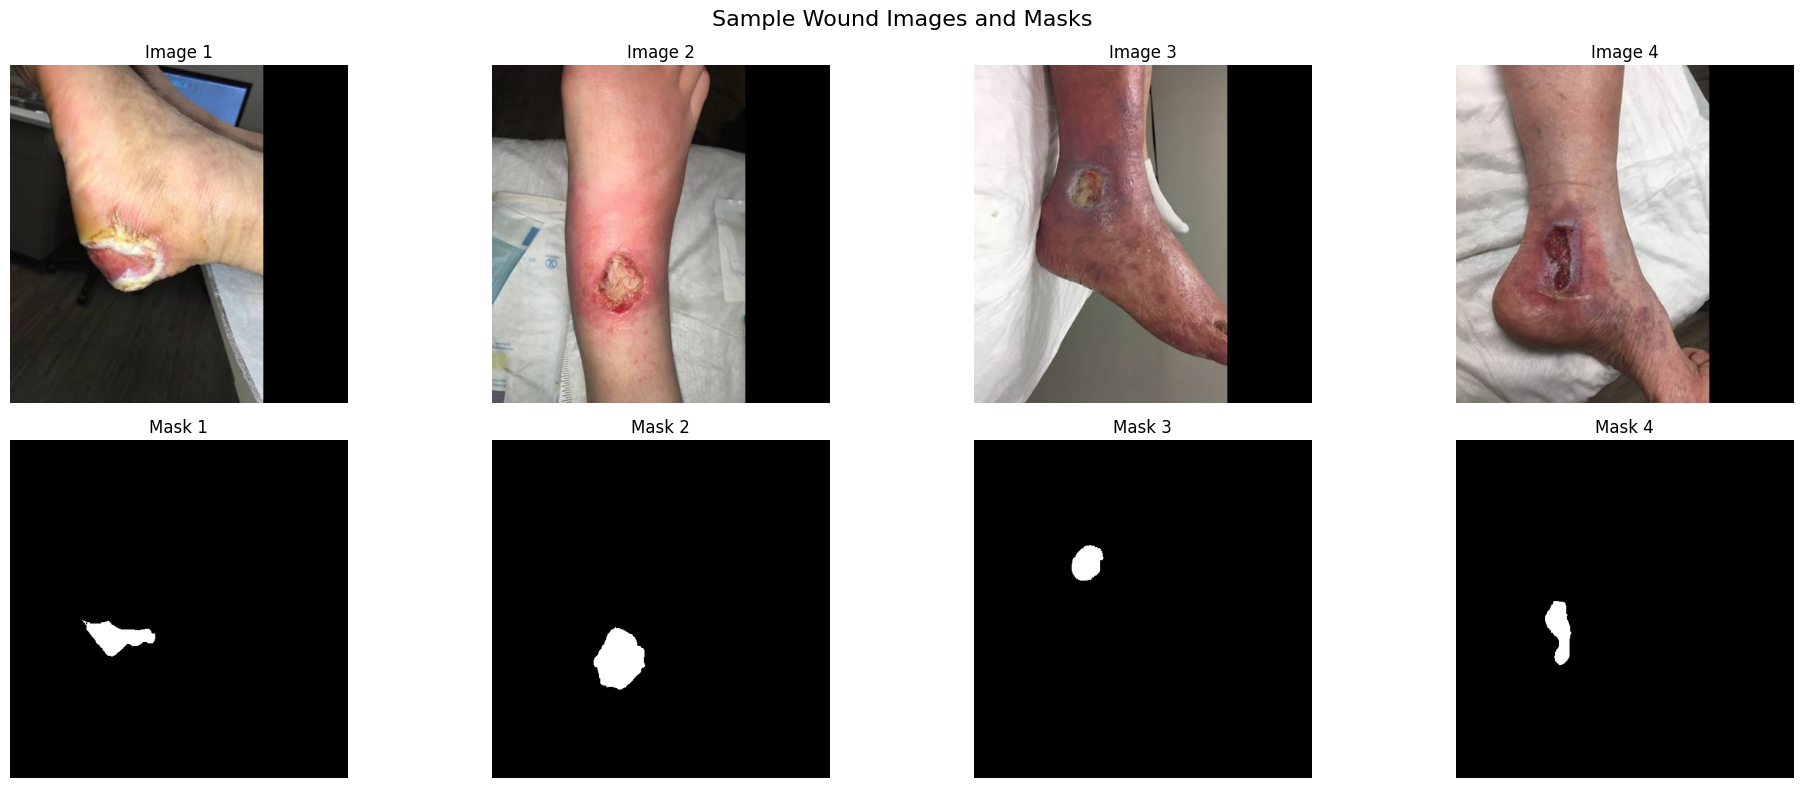

In [5]:
# ============================================================
# CELL 5: Visualize Sample Data
# ============================================================
def show_samples(images, masks, n=4):
    fig, axes = plt.subplots(2, n, figsize=(20, 8))
    for i in range(n):
        img = cv2.imread(images[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(masks[i], cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')
    plt.suptitle('Sample Wound Images and Masks', fontsize=16)
    plt.tight_layout()
    plt.show()

show_samples(train_images, train_masks)

In [6]:
# ============================================================
# CELL 6: Data Generator
# ============================================================
class WoundDataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=8, 
                 img_size=(256, 256), augment=False):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.batch_size  = batch_size
        self.img_size    = img_size
        self.augment     = augment
        self.indices     = np.arange(len(image_paths))

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        images, masks = [], []
        for i in batch_idx:
            img  = cv2.imread(self.image_paths[i])
            img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img  = cv2.resize(img, self.img_size)
            img  = img / 255.0

            mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, self.img_size)
            mask = (mask > 127).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)

            if self.augment:
                if np.random.rand() > 0.5:
                    img  = np.fliplr(img)
                    mask = np.fliplr(mask)
                if np.random.rand() > 0.5:
                    img  = np.flipud(img)
                    mask = np.flipud(mask)
                # Random brightness
                factor = np.random.uniform(0.8, 1.2)
                img    = np.clip(img * factor, 0, 1)

            images.append(img)
            masks.append(mask)

        return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

print('Data Generator ready!')

Data Generator ready!


In [7]:
# ============================================================
# CELL 7: Train/Val Split
# ============================================================
from sklearn.model_selection import train_test_split

train_img, val_img, train_msk, val_msk = train_test_split(
    train_images, train_masks, test_size=VAL_SPLIT, random_state=42
)

print(f'Training:   {len(train_img)} images')
print(f'Validation: {len(val_img)} images')
print(f'Testing:    {len(test_images)} images')

train_gen = WoundDataGenerator(train_img, train_msk, BATCH_SIZE, 
                                (IMG_HEIGHT, IMG_WIDTH), augment=True)
val_gen   = WoundDataGenerator(val_img, val_msk, BATCH_SIZE, 
                                (IMG_HEIGHT, IMG_WIDTH), augment=False)
test_gen  = WoundDataGenerator(test_images, test_masks, BATCH_SIZE, 
                                (IMG_HEIGHT, IMG_WIDTH), augment=False)

Training:   1766 images
Validation: 442 images
Testing:    552 images


In [8]:
# ============================================================
# CELL 8: Loss Functions & Metrics
# ============================================================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def bce_dice_loss(y_true, y_pred):
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

print('Loss functions ready!')

Loss functions ready!


In [9]:
# ============================================================
# CELL 9: U-Net Model
# ============================================================
def conv_block(x, filters, kernel_size=3, dropout_rate=0.1):
    x = Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    x = Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)
    
    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D(2)(c1)
    
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D(2)(c2)
    
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D(2)(c3)
    
    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D(2)(c4)
    
    # Bottleneck
    c5 = conv_block(p4, 1024)
    
    # Decoder
    u6 = Conv2DTranspose(512, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = conv_block(u6, 512)
    
    u7 = Conv2DTranspose(256, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = conv_block(u7, 256)
    
    u8 = Conv2DTranspose(128, 2, strides=2, padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = conv_block(u8, 128)
    
    u9 = Conv2DTranspose(64, 2, strides=2, padding='same')(c8)
    u9 = concatenate([u9, c1])
    c9 = conv_block(u9, 64)
    
    outputs = Conv2D(1, 1, activation='sigmoid')(c9)
    
    model = Model(inputs, outputs, name='U-Net')
    return model

unet_model = build_unet((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
unet_model.compile(
    optimizer=Adam(LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric, 'accuracy']
)
unet_model.summary()

I0000 00:00:1778608675.501911      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778608675.507888      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [10]:
# ============================================================
# CELL 10: U-Net++ Model
# ============================================================
def build_unet_plus_plus(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)
    
    # Encoder
    x00 = conv_block(inputs, 64)
    p0  = MaxPooling2D(2)(x00)
    
    x10 = conv_block(p0, 128)
    p1  = MaxPooling2D(2)(x10)
    
    x20 = conv_block(p1, 256)
    p2  = MaxPooling2D(2)(x20)
    
    x30 = conv_block(p2, 512)
    p3  = MaxPooling2D(2)(x30)
    
    # Bottleneck
    x40 = conv_block(p3, 1024)
    
    # Dense skip connections (U-Net++ feature)
    x01 = conv_block(concatenate([
        x00, Conv2DTranspose(64, 2, strides=2, padding='same')(x10)
    ]), 64)
    
    x11 = conv_block(concatenate([
        x10, Conv2DTranspose(128, 2, strides=2, padding='same')(x20)
    ]), 128)
    
    x21 = conv_block(concatenate([
        x20, Conv2DTranspose(256, 2, strides=2, padding='same')(x30)
    ]), 256)
    
    x02 = conv_block(concatenate([
        x00, x01, Conv2DTranspose(64, 2, strides=2, padding='same')(x11)
    ]), 64)
    
    x12 = conv_block(concatenate([
        x10, x11, Conv2DTranspose(128, 2, strides=2, padding='same')(x21)
    ]), 128)
    
    x03 = conv_block(concatenate([
        x00, x01, x02, Conv2DTranspose(64, 2, strides=2, padding='same')(x12)
    ]), 64)
    
    # Decoder path
    u1 = Conv2DTranspose(512, 2, strides=2, padding='same')(x40)
    d1 = conv_block(concatenate([u1, x30]), 512)
    
    u2 = Conv2DTranspose(256, 2, strides=2, padding='same')(d1)
    d2 = conv_block(concatenate([u2, x20, x21]), 256)
    
    u3 = Conv2DTranspose(128, 2, strides=2, padding='same')(d2)
    d3 = conv_block(concatenate([u3, x10, x11, x12]), 128)
    
    u4 = Conv2DTranspose(64, 2, strides=2, padding='same')(d3)
    d4 = conv_block(concatenate([u4, x00, x01, x02, x03]), 64)
    
    outputs = Conv2D(1, 1, activation='sigmoid')(d4)
    
    model = Model(inputs, outputs, name='U-NetPlusPlus')
    return model

unetpp_model = build_unet_plus_plus((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
unetpp_model.compile(
    optimizer=Adam(LEARNING_RATE),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, iou_metric, 'accuracy']
)
unetpp_model.summary()

Model: "U-NetPlusPlus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 256, 256,  │          0 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     36,928 │ dropout_9[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128, 128,  │          0 │ activation_20[0]… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │    147,584 │ dropout_10[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ activation_21[0]

 Total params: 36,187,137 (138.04 MB)

 Trainable params: 36,172,545 (137.99 MB)

 Non-trainable params: 14,592 (57.00 KB)

In [11]:
# ============================================================
# CELL 11: Callbacks
# ============================================================
def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            f'/kaggle/working/{model_name}_best.keras',
            monitor='val_dice_coefficient',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_dice_coefficient',
            mode='max',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]

print('Callbacks ready!')

Callbacks ready!


In [12]:
# ============================================================
# CELL 12: Train U-Net
# ============================================================
print('🚀 Training U-Net...')
unet_history = unet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('unet'),
    verbose=1
)
print('✅ U-Net Training Complete!')

🚀 Training U-Net...
Epoch 1/50


I0000 00:00:1778608690.291412      82 service.cc:152] XLA service 0x7d5590008bc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778608690.291454      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778608690.291461      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778608692.582360      82 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-12 17:58:27.083622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:58:27.301098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:58:31.886889: E external/local_xl

 94/221 ━━━━━━━━━━━━━━━━━━━━ 58s 457ms/step - accuracy: 0.8176 - dice_coefficient: 0.1375 - iou_metric: 0.1707 - loss: 1.3497

2026-05-12 17:59:54.690169: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:59:54.914344: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:59:55.982602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 17:59:56.285318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 18:00:04.540961: E external/local_xla/xla/stream_

221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.8755 - dice_coefficient: 0.1704 - iou_metric: 0.2390 - loss: 1.2234

2026-05-12 18:02:01.754529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 18:02:01.974120: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 18:02:02.812418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 18:02:03.110410: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 18:02:08.670950: E external/local_xla/xla/stream_


Epoch 1: val_dice_coefficient improved from -inf to 0.06835, saving model to /kaggle/working/unet_best.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 254s 849ms/step - accuracy: 0.8757 - dice_coefficient: 0.1706 - iou_metric: 0.2393 - loss: 1.2227 - val_accuracy: 0.9537 - val_dice_coefficient: 0.0684 - val_iou_metric: 0.0164 - val_loss: 1.1192 - learning_rate: 1.0000e-04
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9579 - dice_coefficient: 0.3423 - iou_metric: 0.4019 - loss: 0.8264
Epoch 2: val_dice_coefficient improved from 0.06835 to 0.23743, saving model to /kaggle/working/unet_best.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 119s 537ms/step - accuracy: 0.9579 - dice_coefficient: 0.3424 - iou_metric: 0.4019 - loss: 0.8262 - val_accuracy: 0.9619 - val_dice_coefficient: 0.2374 - val_iou_metric: 0.2180 - val_loss: 0.9084 - learning_rate: 1.0000e-04
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9674 - dice_coefficient: 0.4605 - iou_metric: 0.4865 - loss: 0.6583


In [13]:
# ============================================================
# CELL 13: Train U-Net++
# ============================================================
print('🚀 Training U-Net++...')
unetpp_history = unetpp_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=get_callbacks('unetpp'),
    verbose=1
)
print('✅ U-Net++ Training Complete!')

🚀 Training U-Net++...
Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8452 - dice_coefficient: 0.1533 - iou_metric: 0.2171 - loss: 1.2963
Epoch 1: val_dice_coefficient improved from -inf to 0.06207, saving model to /kaggle/working/unetpp_best.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.8456 - dice_coefficient: 0.1535 - iou_metric: 0.2174 - loss: 1.2954 - val_accuracy: 0.9536 - val_dice_coefficient: 0.0621 - val_iou_metric: 0.0054 - val_loss: 1.1363 - learning_rate: 1.0000e-04
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9497 - dice_coefficient: 0.2911 - iou_metric: 0.3512 - loss: 0.8954
Epoch 2: val_dice_coefficient improved from 0.06207 to 0.21385, saving model to /kaggle/working/unetpp_best.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.9497 - dice_coefficient: 0.2913 - iou_metric: 0.3513 - loss: 0.8952 - val_accuracy: 0.9622 - val_dice_coefficient: 0.2138 - val_iou_metric: 0.2181 - val_loss: 0.9335 - learning_rate

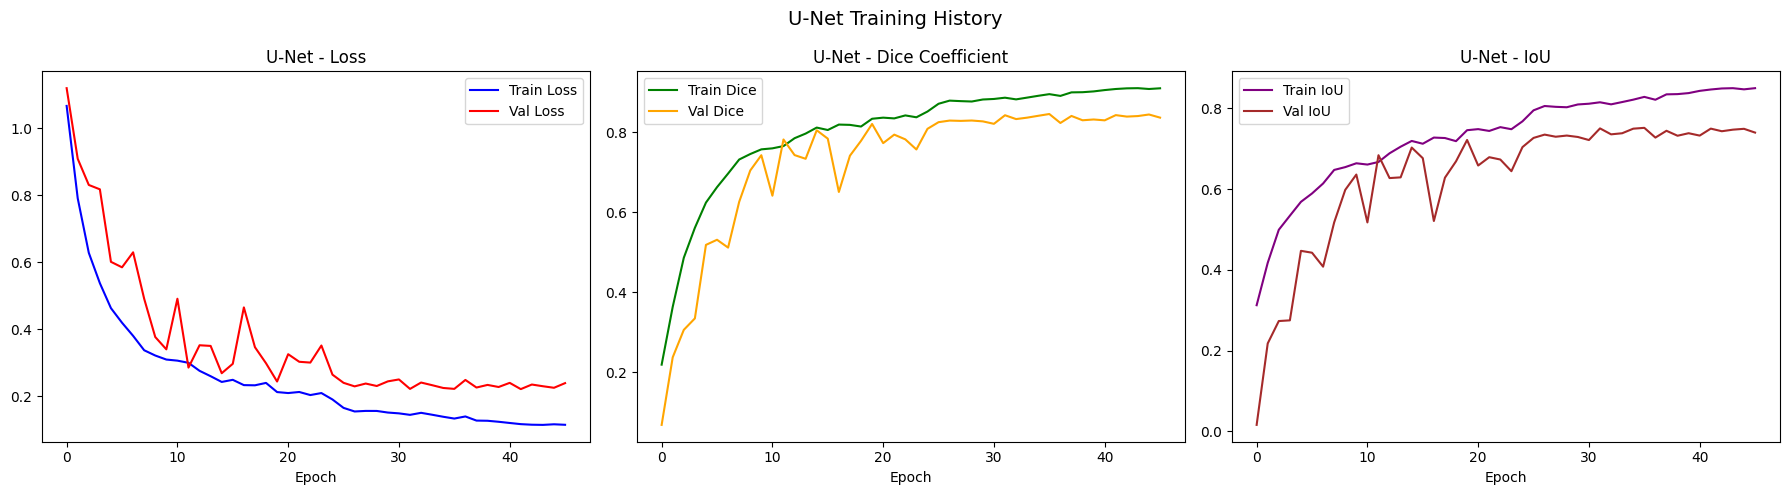

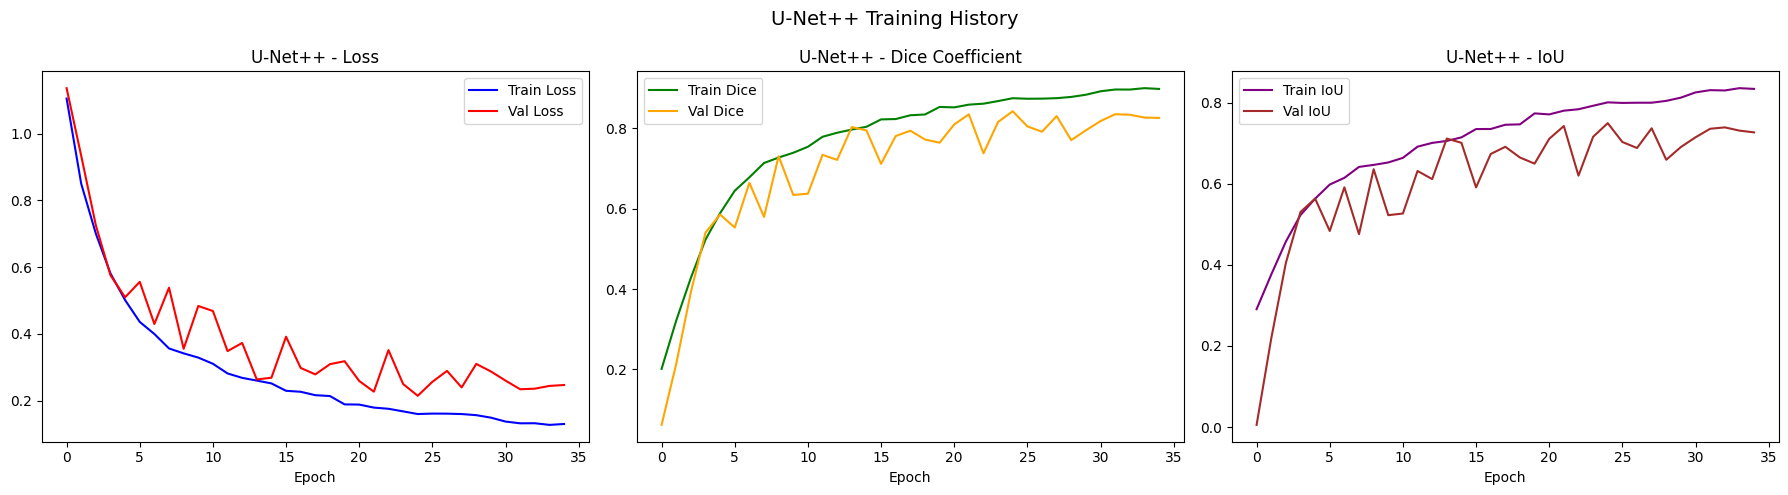

In [14]:
# ============================================================
# CELL 14: Plot Training Curves
# ============================================================
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='red')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].set_xlabel('Epoch')
    
    # Dice
    axes[1].plot(history.history['dice_coefficient'], label='Train Dice', color='green')
    axes[1].plot(history.history['val_dice_coefficient'], label='Val Dice', color='orange')
    axes[1].set_title(f'{model_name} - Dice Coefficient')
    axes[1].legend()
    axes[1].set_xlabel('Epoch')
    
    # IoU
    axes[2].plot(history.history['iou_metric'], label='Train IoU', color='purple')
    axes[2].plot(history.history['val_iou_metric'], label='Val IoU', color='brown')
    axes[2].set_title(f'{model_name} - IoU')
    axes[2].legend()
    axes[2].set_xlabel('Epoch')
    
    plt.suptitle(f'{model_name} Training History', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_history.png', dpi=150)
    plt.show()

plot_history(unet_history, 'U-Net')
plot_history(unetpp_history, 'U-Net++')

In [15]:
# ============================================================
# CELL 15: Evaluate on Test Set
# ============================================================
def evaluate_model(model, test_gen, model_name):
    results = model.evaluate(test_gen, verbose=1)
    print(f'\n📊 {model_name} Test Results:')
    print(f'  Loss:             {results[0]:.4f}')
    print(f'  Dice Coefficient: {results[1]:.4f}')
    print(f'  IoU:              {results[2]:.4f}')
    print(f'  Accuracy:         {results[3]:.4f}')
    return results

unet_results   = evaluate_model(unet_model, test_gen, 'U-Net')
unetpp_results = evaluate_model(unetpp_model, test_gen, 'U-Net++')

69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 198ms/step - accuracy: 0.9959 - dice_coefficient: 0.8366 - iou_metric: 0.7378 - loss: 0.1800

📊 U-Net Test Results:
  Loss:             0.1712
  Dice Coefficient: 0.8450
  IoU:              0.7493
  Accuracy:         0.9960
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 412ms/step - accuracy: 0.9956 - dice_coefficient: 0.8023 - iou_metric: 0.7018 - loss: 0.2139

📊 U-Net++ Test Results:
  Loss:             0.2089
  Dice Coefficient: 0.8089
  IoU:              0.7115
  Accuracy:         0.9955


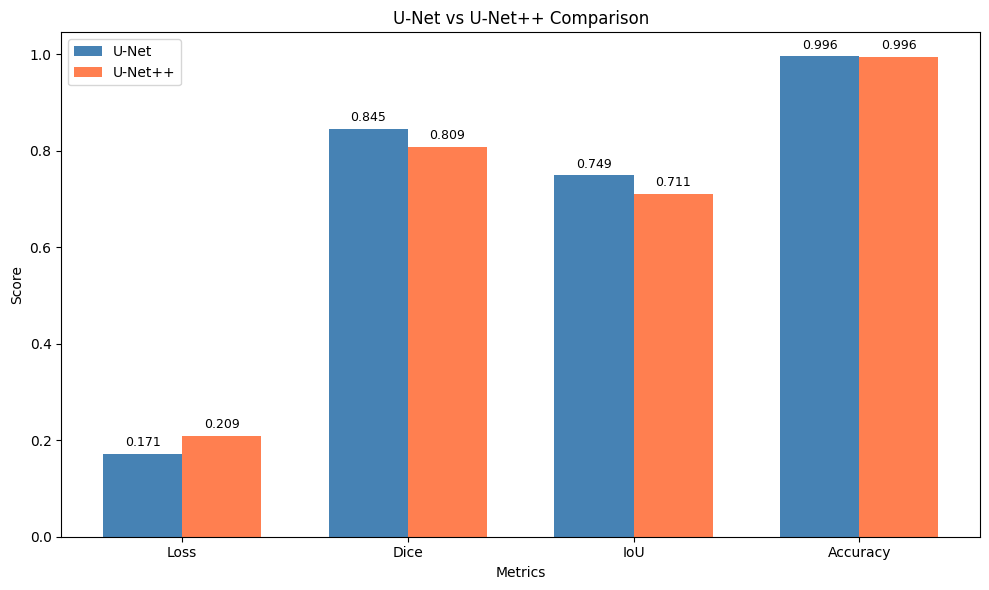

In [16]:
# ============================================================
# CELL 16: Compare Models
# ============================================================
metrics = ['Loss', 'Dice', 'IoU', 'Accuracy']
unet_vals   = unet_results
unetpp_vals = unetpp_results

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, unet_vals,   width, label='U-Net',   color='steelblue')
bars2 = ax.bar(x + width/2, unetpp_vals, width, label='U-Net++', color='coral')

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('U-Net vs U-Net++ Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150)
plt.show()

2026-05-12 22:21:37.436918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 22:21:37.638397: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 22:21:38.140010: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 22:21:38.400692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 22:21:41.255525: E external/local_xla/xla/stream_

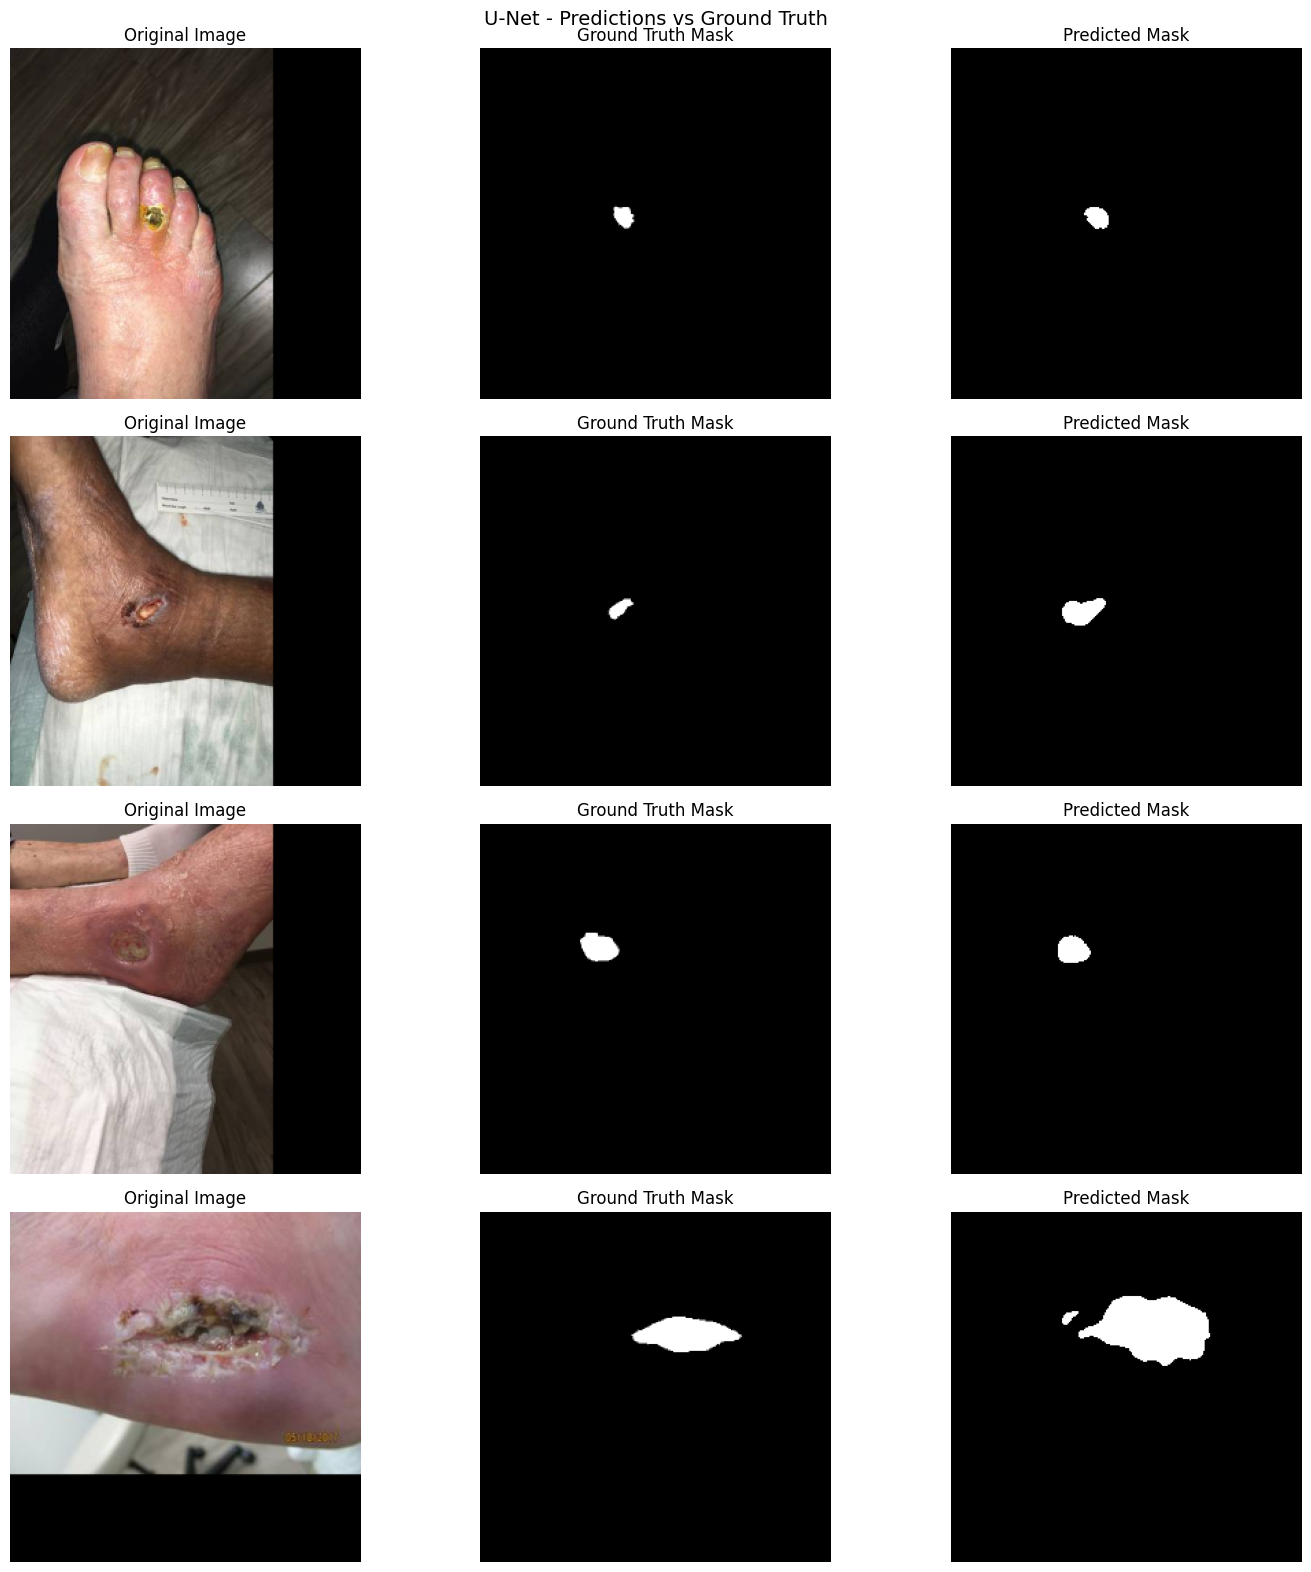

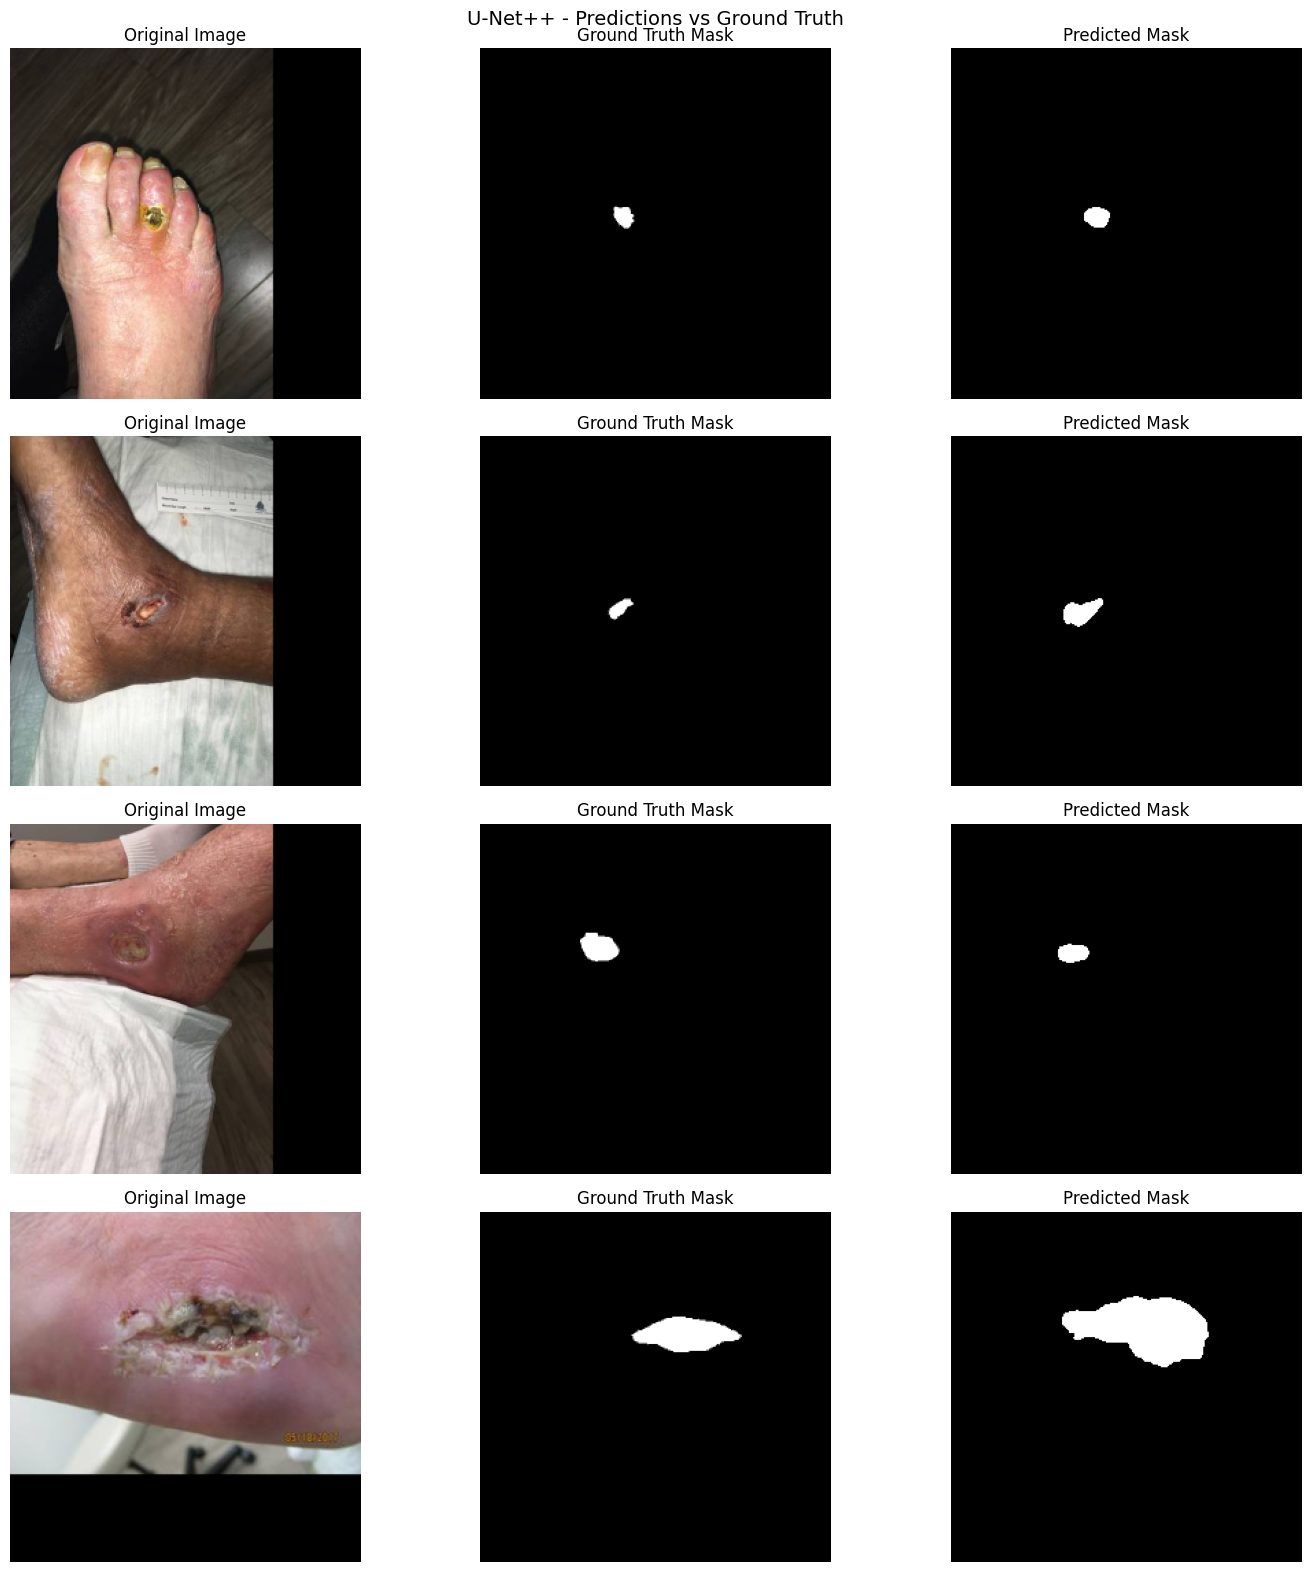

In [17]:
# ============================================================
# CELL 17: Visualize Predictions
# ============================================================
def visualize_predictions(model, image_paths, mask_paths, model_name, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(15, n * 4))
    
    for i in range(n):
        img  = cv2.imread(image_paths[i])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img  = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        
        mask = cv2.imread(mask_paths[i], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        
        inp  = img / 255.0
        inp  = np.expand_dims(inp, axis=0)
        pred = model.predict(inp, verbose=0)[0, :, :, 0]
        pred = (pred > 0.5).astype(np.uint8) * 255
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth Mask')
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title('Predicted Mask')
        axes[i, 2].axis('off')
    
    plt.suptitle(f'{model_name} - Predictions vs Ground Truth', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_predictions.png', dpi=150)
    plt.show()

visualize_predictions(unet_model,   test_images, test_masks, 'U-Net')
visualize_predictions(unetpp_model, test_images, test_masks, 'U-Net++')

In [18]:
# ============================================================
# CELL 18: Save Models
# ============================================================
unet_model.save('/kaggle/working/unet_wound_final.keras')
unetpp_model.save('/kaggle/working/unetpp_wound_final.keras')

print('✅ Models saved successfully!')
print('📁 Files saved:')
for f in os.listdir('/kaggle/working/'):
    print(f'   {f}')

✅ Models saved successfully!
📁 Files saved:
   U-Net_history.png
   unetpp_best.keras
   U-Net++_history.png
   unetpp_wound_final.keras
   unet_best.keras
   model_comparison.png
   __notebook__.ipynb
   unet_wound_final.keras
   U-Net_predictions.png
   U-Net++_predictions.png


In [1]:
# ============================================================
# CELL 19: Wound Severity + Healing Prediction
# ============================================================
import os, cv2, numpy as np, pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import backend as K

# ── Paths ──────────────────────────────────────────────────
BASE_DIR       = r"C:\Users\subhangini\OneDrive\Desktop\Wound-Segmentation\dataset"
TEST_IMAGE_DIR = os.path.join(BASE_DIR, "test_images")
TEST_MASK_DIR  = os.path.join(BASE_DIR, "test_masks")

test_images = sorted(glob(os.path.join(TEST_IMAGE_DIR, "*.png")))
test_masks  = sorted(glob(os.path.join(TEST_MASK_DIR,  "*.png")))

IMG_HEIGHT, IMG_WIDTH = 256, 256

print(f"Test images found: {len(test_images)}")

# ── Model load ─────────────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(K.round(y_pred))
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def bce_dice_loss(y_true, y_pred):
    bce  = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = 1 - dice_coefficient(y_true, y_pred)
    return bce + dice

MODEL_PATH = r"C:\Users\subhangini\OneDrive\Desktop\Wound-Segmentation\unet_best.keras"

unet_model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'bce_dice_loss':    bce_dice_loss,
        'dice_coefficient': dice_coefficient,
        'iou_metric':       iou_metric
    }
)
print("Model loaded successfully!")

# ── Functions ──────────────────────────────────────────────
def get_wound_area_pct(mask):
    total  = mask.shape[0] * mask.shape[1]
    wound  = cv2.countNonZero(mask)
    return round((wound / total) * 100, 2)

def estimate_healing_days(wound_area_pct):
    if wound_area_pct <= 0:
        return {"severity": "No Wound", "days": 0,
                "range": "N/A", "advice": "No wound detected."}
    elif wound_area_pct <= 5:
        severity = "Mild"
        days     = int(7  + wound_area_pct * 1.4)
        rng      = f"{days-2}–{days+3} days"
        advice   = "Minor wound. Clean daily, keep covered."
    elif wound_area_pct <= 15:
        severity = "Moderate"
        days     = int(14 + wound_area_pct * 1.6)
        rng      = f"{days-3}–{days+5} days"
        advice   = "Change dressing every 2 days. See doctor if no improvement in 1 week."
    elif wound_area_pct <= 30:
        severity = "Severe"
        days     = int(30 + wound_area_pct * 1.8)
        rng      = f"{days-5}–{days+10} days"
        advice   = "Daily dressing needed. Consult doctor immediately."
    else:
        severity = "Critical"
        days     = int(60 + wound_area_pct * 2.0)
        rng      = f"{days-7}–{days+14} days"
        advice   = "Emergency medical attention required."
    return {"severity": severity, "days": days,
            "range": rng, "advice": advice}

# ── Run on test images ─────────────────────────────────────
print("\n" + "="*55)
print("  WOUND SEVERITY + HEALING PREDICTION — TEST RESULTS")
print("="*55)

results = []

for i in range(min(10, len(test_images))):
    img  = cv2.imread(test_images[i])
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    inp  = np.expand_dims(img / 255.0, axis=0).astype(np.float32)
    pred = unet_model.predict(inp, verbose=0)[0, :, :, 0]
    mask = (pred > 0.5).astype(np.uint8)

    area_pct = get_wound_area_pct(mask)
    result   = estimate_healing_days(area_pct)

    results.append({
        "Image":        f"test_{i+1}",
        "Wound Area %": area_pct,
        "Severity":     result["severity"],
        "Est. Days":    result["days"],
        "Range":        result["range"]
    })

    print(f"\nImage {i+1}:")
    print(f"  Wound Area : {area_pct}%")
    print(f"  Severity   : {result['severity']}")
    print(f"  Healing    : ~{result['days']} days  ({result['range']})")
    print(f"  Advice     : {result['advice']}")

print("\n" + "="*55)

df_results = pd.DataFrame(results)
print("\nSummary Table:")
print(df_results.to_string(index=False))

Test images found: 552
Model loaded successfully!

  WOUND SEVERITY + HEALING PREDICTION — TEST RESULTS

Image 1:
  Wound Area : 0.36%
  Severity   : Mild
  Healing    : ~7 days  (5–10 days)
  Advice     : Minor wound. Clean daily, keep covered.

Image 2:
  Wound Area : 0.64%
  Severity   : Mild
  Healing    : ~7 days  (5–10 days)
  Advice     : Minor wound. Clean daily, keep covered.

Image 3:
  Wound Area : 0.54%
  Severity   : Mild
  Healing    : ~7 days  (5–10 days)
  Advice     : Minor wound. Clean daily, keep covered.

Image 4:
  Wound Area : 4.62%
  Severity   : Mild
  Healing    : ~13 days  (11–16 days)
  Advice     : Minor wound. Clean daily, keep covered.

Image 5:
  Wound Area : 4.42%
  Severity   : Mild
  Healing    : ~13 days  (11–16 days)
  Advice     : Minor wound. Clean daily, keep covered.

Image 6:
  Wound Area : 0.57%
  Severity   : Mild
  Healing    : ~7 days  (5–10 days)
  Advice     : Minor wound. Clean daily, keep covered.

Image 7:
  Wound Area : 1.9%
  Severity

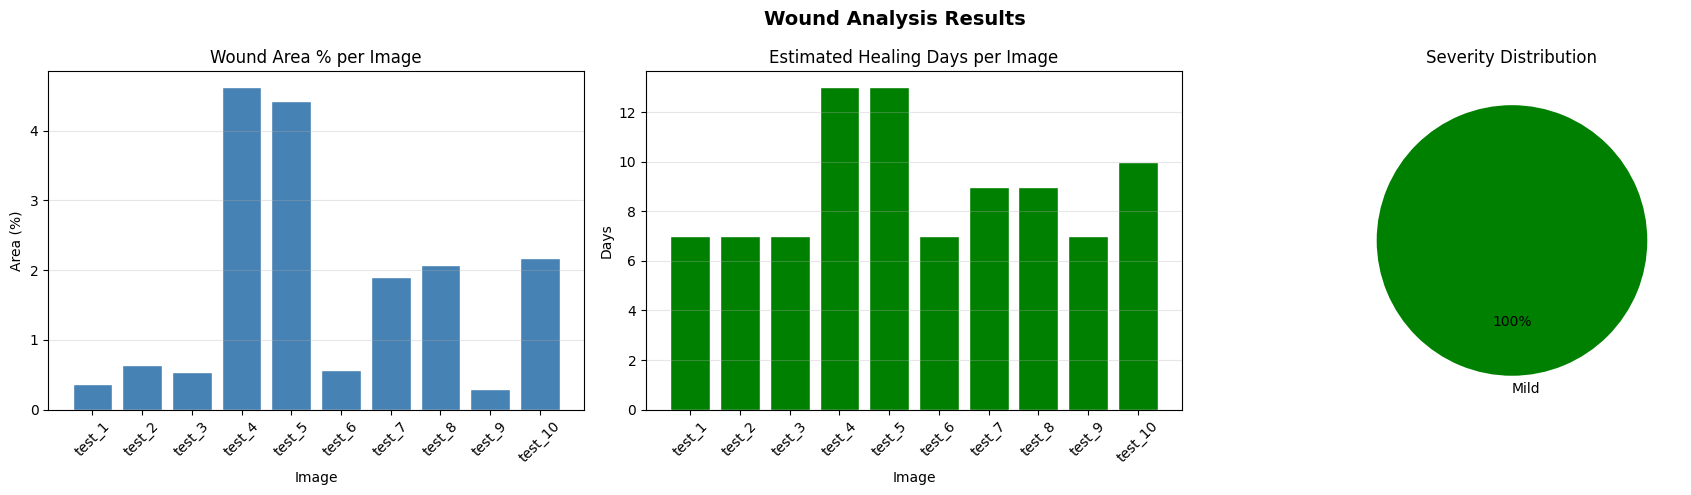

Graph saved: wound_healing_results.png


In [2]:
# ============================================================
# CELL 20: Results Visualization
# Cell 19 ke BAAD add karo
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Wound Area % per image ---
axes[0].bar(df_results["Image"],
            df_results["Wound Area %"],
            color="steelblue", edgecolor="white")
axes[0].set_title("Wound Area % per Image")
axes[0].set_xlabel("Image")
axes[0].set_ylabel("Area (%)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Estimated Healing Days ---
color_map = {
    "Mild":     "green",
    "Moderate": "orange",
    "Severe":   "red",
    "Critical": "darkred"
}
bar_colors = [color_map.get(s, "gray") for s in df_results["Severity"]]

axes[1].bar(df_results["Image"],
            df_results["Est. Days"],
            color=bar_colors, edgecolor="white")
axes[1].set_title("Estimated Healing Days per Image")
axes[1].set_xlabel("Image")
axes[1].set_ylabel("Days")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# --- Plot 3: Severity Distribution (Pie chart) ---
severity_counts = df_results["Severity"].value_counts()
pie_colors = [color_map.get(s, "gray") for s in severity_counts.index]
axes[2].pie(severity_counts.values,
            labels=severity_counts.index,
            colors=pie_colors,
            autopct="%1.0f%%",
            startangle=90)
axes[2].set_title("Severity Distribution")

plt.suptitle("Wound Analysis Results", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\subhangini\OneDrive\Desktop\Wound-Segmentation\wound_healing_results.png', dpi=150)
plt.show()

print("Graph saved: wound_healing_results.png")